## Conditional Workflows ##

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class QState(TypedDict):
    a: int
    b: int
    c: int

    equation: float
    descriment: float
    result: float


def show_equation(state: QState):
    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'
    return {"equation": equation}

def calculate_descriment(state: QState):
    descriment = state["b"]**2-(4*state["a"]*state["c"])
    return {"descriment": descriment}

In [2]:
graph = StateGraph(QState)

graph.add_node("show_equation",show_equation)
graph.add_node("calculate_descriment",calculate_descriment)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_descriment")
graph.add_edge("calculate_descriment",END)

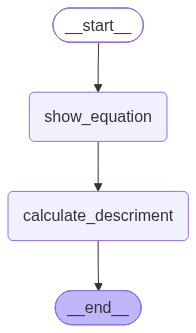

In [3]:
workflow = graph.compile()